# Estimation d'Âge par Deep Learning — Rapport Complet

**Dataset :** APPA-REAL (Apparent and Real Age)  
**Backbone :** SE-ResNeXt50-32x4d pré-entraîné sur ImageNet  
**Méthodes étudiées :** DEX (Cross-Entropy), DEX (Gaussian Loss), Residual DEX

---

## Plan du rapport

1. **Analyse du Backbone** — Validation de l'extracteur de caractéristiques
2. **Méthode DEX — Cross-Entropy Loss** — Entraînement et évaluation
3. **Méthode DEX — Gaussian Loss** — Entraînement et évaluation  
4. **Méthode Residual DEX** — Extension avec correction résiduelle
5. **Comparaison et Conclusion**

### Configuration de l'environnement

In [1]:
# ============================================================
# Setup global
# ============================================================
import os, sys, gc, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch import amp
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
from pathlib import Path
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Execution sur : {str(device).upper()} ---")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} Go")

os.chdir('/Data/gregoire/Deep-learning-project')
sys.path.insert(0, os.getcwd())
print(f"Repertoire : {os.getcwd()}")

--- Execution sur : CUDA ---
GPU : NVIDIA RTX A4000
VRAM : 15.6 Go
Repertoire : /Data/gregoire/Deep-learning-project


In [2]:
# ============================================================
# Installation des dependances
# ============================================================
!pip install pretrainedmodels albumentations opencv-python seaborn scikit-learn -q
print("Dependances pretes.")

Dependances pretes.


---
# Partie 0 — Analyse du Backbone : SE-ResNeXt50-32x4d

## Introduction

Avant d'entraîner un modèle d'estimation d'âge, il est essentiel de valider la qualité du **backbone** (extracteur de caractéristiques) que nous allons utiliser.

### Architecture SE-ResNeXt50-32x4d

Le backbone utilisé dans ce projet est le **SE-ResNeXt50-32x4d**

### Protocole de validation

Pour valider que ce backbone extrait des features discriminantes sur les visages **sans aucun fine-tuning**, nous effectuons un test de clustering non supervisé :
- Données : visages LFW vs objets CIFAR-10
- Méthode : features → normalisation L2 → K-means ($k=2$)


### Paramètres — Backbone 

In [3]:
# ============================================================
# PARAMETRES — Backbone Probe (modifier ici)
# ============================================================

BACKBONE_BATCH_SIZE = 128   # Taille des batches pour l'extraction
N_CLUSTERS          = 2     # Nombre de clusters K-means

print(f"Batch size extraction : {BACKBONE_BATCH_SIZE}")
print(f"K-means clusters      : {N_CLUSTERS}")

Batch size extraction : 128
K-means clusters      : 2


In [4]:
# ============================================================
# Chargement du backbone SE-ResNeXt50
# ============================================================
from model import get_model

backbone = get_model(model_name="se_resnext50_32x4d", num_classes=101, pretrained="imagenet")
backbone.last_linear = nn.Identity()
backbone = backbone.to(device)
backbone.eval()
for param in backbone.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in backbone.parameters())
print(f"Backbone charge : {total_params:,} parametres (tous geles)")

Backbone charge : 25,510,896 parametres (tous geles)


### Extraction des features et clustering

Nous extrayons les représentations vectorielles produites par le backbone pour chaque image, puis appliquons K-means avec $k=2$ clusters.


In [5]:
# ============================================================
# Donnees LFW + CIFAR-10
# ============================================================
from torchvision import datasets, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.datasets import fetch_lfw_people
from PIL import Image

print("Telechargement LFW (visages)...")
lfw = fetch_lfw_people(min_faces_per_person=1, resize=1.0, color=True)
lfw_images = lfw.images
print(f"   LFW : {len(lfw_images)} images")

print("Telechargement CIFAR-10 (non-visages)...")
cifar_a = datasets.CIFAR10(root="./data", download=True, train=True)
cifar_b = datasets.CIFAR10(root="./data", download=True, train=False)
print(f"   CIFAR-10 : {len(cifar_a) + len(cifar_b)} images")

transform_bb = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class LFWDataset(Dataset):
    def __init__(self, images, transform=None):
        self.images = images; self.transform = transform
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = Image.fromarray((self.images[idx] * 255).astype(np.uint8))
        return self.transform(img) if self.transform else img, 1

class CIFARDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset; self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        return self.transform(img) if self.transform else img, 0

lfw_ds     = LFWDataset(lfw_images, transform=transform_bb)
cifar_full = ConcatDataset([CIFARDataset(cifar_a, transform_bb), CIFARDataset(cifar_b, transform_bb)])

n = min(len(lfw_ds), len(cifar_full))
lfw_sub,   _ = random_split(lfw_ds,     [n, len(lfw_ds)    - n])
cifar_sub, _ = random_split(cifar_full, [n, len(cifar_full) - n])
full_ds = ConcatDataset([lfw_sub, cifar_sub])
loader_bb = DataLoader(full_ds, batch_size=BACKBONE_BATCH_SIZE, shuffle=False, num_workers=2)
print(f"\n{n} visages + {n} non-visages = {n*2} images")

Telechargement LFW (visages)...
   LFW : 13233 images
Telechargement CIFAR-10 (non-visages)...
   CIFAR-10 : 60000 images

13233 visages + 13233 non-visages = 26466 images


Extraction des features backbone...
   batch 0/207...
   batch 20/207...
   batch 40/207...
   batch 60/207...
   batch 80/207...
   batch 100/207...
   batch 120/207...
   batch 140/207...
   batch 160/207...
   batch 180/207...
   batch 200/207...
   Features : (26466, 2048)


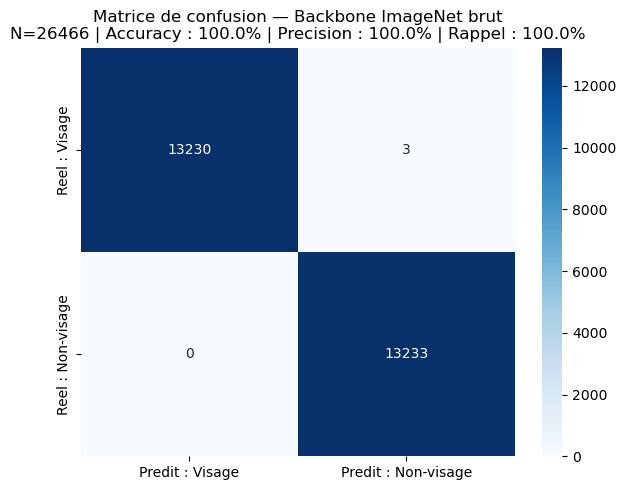

TP:13230 TN:13233 FP:0 FN:3
Accuracy:100.0%  Precision:100.0%  Rappel:100.0%
Le backbone separe naturellement les visages.


In [6]:
# ============================================================
# Extraction features + K-means + Matrice de confusion
# ============================================================
print("Extraction des features backbone...")
backbone.eval()
all_feats, all_labels = [], []

with torch.no_grad():
    for i, (imgs, labels) in enumerate(loader_bb):
        feats = backbone(imgs.to(device)).cpu().numpy()
        all_feats.append(feats); all_labels.append(labels.numpy())
        if i % 20 == 0: print(f"   batch {i}/{len(loader_bb)}...")

all_feats  = normalize(np.concatenate(all_feats), norm="l2")
all_labels = np.concatenate(all_labels)
print(f"   Features : {all_feats.shape}")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(all_feats)
if np.mean((1 - cluster_labels) == all_labels) > np.mean(cluster_labels == all_labels):
    cluster_labels = 1 - cluster_labels

TP = int(((cluster_labels==1)&(all_labels==1)).sum())
TN = int(((cluster_labels==0)&(all_labels==0)).sum())
FP = int(((cluster_labels==1)&(all_labels==0)).sum())
FN = int(((cluster_labels==0)&(all_labels==1)).sum())
accuracy  = (TP+TN)/(TP+TN+FP+FN)
precision = TP/(TP+FP) if (TP+FP)>0 else 0
recall    = TP/(TP+FN) if (TP+FN)>0 else 0

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(np.array([[TP,FN],[FP,TN]]), annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predit : Visage","Predit : Non-visage"],
    yticklabels=["Reel : Visage","Reel : Non-visage"], ax=ax)
ax.set_title(f"Matrice de confusion — Backbone ImageNet brut\nN={n*2} | Accuracy : {accuracy:.1%} | Precision : {precision:.1%} | Rappel : {recall:.1%}")
plt.tight_layout(); plt.savefig("backbone_confusion.png", dpi=150); plt.show()

print(f"TP:{TP} TN:{TN} FP:{FP} FN:{FN}")
print(f"Accuracy:{accuracy:.1%}  Precision:{precision:.1%}  Rappel:{recall:.1%}")
if accuracy > 0.85:   print("Le backbone separe naturellement les visages.")
elif accuracy > 0.70: print("Separation partielle.")
else:                 print("Pas de separation claire (~50% aleatoire).")

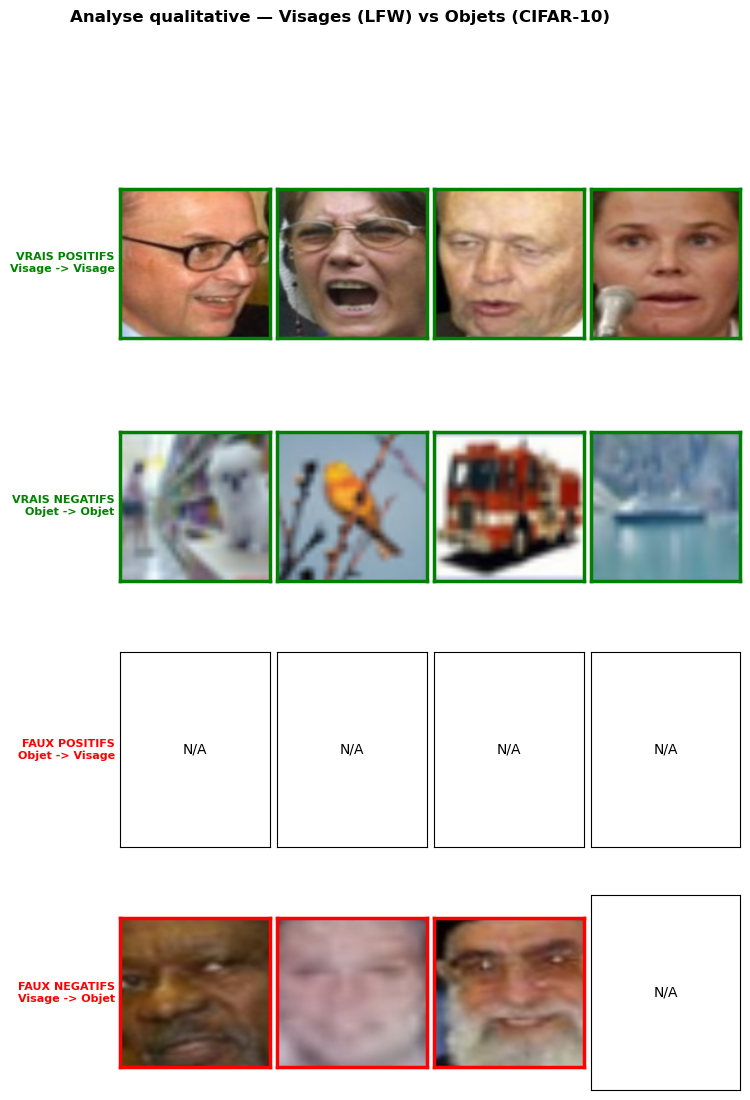

In [7]:
# ============================================================
# Visualisation qualitative TP/TN/FP/FN
# ============================================================
N_SHOW = 4
idx_TP = np.where((cluster_labels==1)&(all_labels==1))[0]
idx_TN = np.where((cluster_labels==0)&(all_labels==0))[0]
idx_FP = np.where((cluster_labels==1)&(all_labels==0))[0]
idx_FN = np.where((cluster_labels==0)&(all_labels==1))[0]

def get_img_display(dataset, idx):
    img, _ = dataset[idx]
    if isinstance(img, torch.Tensor):
        mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
        std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
        return torch.clamp(img*std+mean,0,1).permute(1,2,0).numpy()
    return np.array(img)

cases = [
    (idx_TP,"VRAIS POSITIFS\nVisage -> Visage","green"),
    (idx_TN,"VRAIS NEGATIFS\nObjet -> Objet","green"),
    (idx_FP,"FAUX POSITIFS\nObjet -> Visage","red"),
    (idx_FN,"FAUX NEGATIFS\nVisage -> Objet","red"),
]
fig, axes = plt.subplots(4, N_SHOW, figsize=(N_SHOW*2.5, 4*3))
for row, (indices, title, color) in enumerate(cases):
    axes[row,0].set_ylabel(title, fontsize=8, fontweight="bold", rotation=0, ha="right", va="center", color=color)
    sample = np.random.choice(indices, size=min(N_SHOW,len(indices)), replace=False) if len(indices)>0 else []
    for col in range(N_SHOW):
        ax = axes[row,col]
        if col < len(sample):
            ax.imshow(get_img_display(full_ds, sample[col]))
            for sp in ax.spines.values(): sp.set_edgecolor(color); sp.set_linewidth(2.5); sp.set_visible(True)
        else:
            ax.text(0.5,0.5,"N/A",ha="center",va="center")
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Analyse qualitative — Visages (LFW) vs Objets (CIFAR-10)", fontsize=12, fontweight="bold", y=1.01)
plt.subplots_adjust(left=0.28, wspace=0.05, hspace=0.25)
plt.savefig("backbone_qualitative.png", dpi=150, bbox_inches='tight'); plt.show()

---
# Présentation du Dataset APPA-REAL

Le dataset **APPA-REAL** (Apparent and Real Age) contient des photos de visages annotées par des évaluateurs humains. Pour chaque image :

- $y_{\text{real}}$ : âge réel de la personne
- $\bar{y}_{\text{app}}$ : moyenne des estimations d'âge apparent par les annotateurs  
- $\sigma_{\text{app}}$ : écart-type des estimations (indicateur d'ambiguïté)

Cette dualité est centrale : DEX prédit l'âge **apparent**, Residual DEX corrige vers l'âge **réel**.

### Paramètres — Dataset global

In [8]:
BATCH_SIZE  = 32     # Batch size par defaut (peut etre surcharge par partie)
NUM_CLASSES = 101    # Classes d'age : 0 a 100 ans
DATA_ROOT   = Path("appa-real-release")

print(f"Batch size  : {BATCH_SIZE}")
print(f"Nb classes  : {NUM_CLASSES}")
print(f"Data root   : {DATA_ROOT.resolve()}")

Batch size  : 32
Nb classes  : 101
Data root   : /Data/gregoire/Deep-learning-project/appa-real-release


In [9]:
# ============================================================
# Classe AgeDataset commune
# ============================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2

class AgeDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, num_classes=101):
        self.img_dir = Path(img_dir); self.transform = transform; self.num_classes = num_classes
        df = pd.read_csv(csv_path)
        df = df[df["file_name"].apply(lambda x: (self.img_dir / x).exists())].reset_index(drop=True)
        self.df = df
        self.age_col = "apparent_age_avg" if "apparent_age_avg" in df.columns else "apparent_age"
        print(f"   {self.img_dir.name} : {len(df)} images valides")
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        age      = float(row[self.age_col])
        real_age = float(row["real_age"]) if "real_age" in self.df.columns else age
        std      = float(row["apparent_age_std"]) if "apparent_age_std" in self.df.columns else 2.0
        img = cv2.imread(str(self.img_dir / row["file_name"]))
        img = np.zeros((224,224,3), dtype=np.uint8) if img is None else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform: img = self.transform(image=img)["image"]
        age_class = max(0, min(self.num_classes-1, int(round(age))))
        return img, age_class, age, real_age, std

train_transform = A.Compose([
    A.Resize(224,224), A.HorizontalFlip(p=0.5), A.RandomBrightnessContrast(p=0.2),
    A.Affine(translate_percent=0.05, scale=(0.95,1.05), rotate=(-15,15), p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2(),
])
valid_transform = A.Compose([
    A.Resize(224,224), A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)), ToTensorV2(),
])

print("Chargement APPA-REAL :")
train_ds = AgeDataset(DATA_ROOT/"gt_avg_train.csv", DATA_ROOT/"train", train_transform)
valid_ds = AgeDataset(DATA_ROOT/"gt_avg_valid.csv", DATA_ROOT/"valid", valid_transform)
test_ds  = AgeDataset(DATA_ROOT/"gt_avg_test.csv",  DATA_ROOT/"test",  valid_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"\nTrain : {len(train_ds)} | Valid : {len(valid_ds)} | Test : {len(test_ds)}")

Chargement APPA-REAL :
   train : 4103 images valides
   valid : 1497 images valides
   test : 1977 images valides

Train : 4103 | Valid : 1497 | Test : 1977


In [10]:
# ================
# Modele DEX 
# ================
from model import get_model

class DEXModel(nn.Module):
    def __init__(self, num_classes=101, dropout=0.5):
        super().__init__()
        self.feature_extractor = get_model("se_resnext50_32x4d", num_classes=num_classes, pretrained="imagenet")
        dim = self.feature_extractor.last_linear.in_features
        self.feature_extractor.last_linear = nn.Sequential(
            nn.Dropout(p=dropout), nn.Linear(dim,512), nn.ReLU(inplace=True),
            nn.Dropout(p=dropout), nn.Linear(512,num_classes),
        )
    def forward(self, x):
        logits = self.feature_extractor(x)
        return logits, torch.softmax(logits, dim=1)

def calculate_expected_age(probs, device):
    age_range = torch.arange(0, probs.size(1), dtype=torch.float32, device=device)
    return torch.sum(probs * age_range.unsqueeze(0), dim=1)

def denormalize(img_tensor):
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return torch.clamp(img_tensor.cpu()*std+mean, 0, 1).permute(1,2,0).numpy()

print("Classe DEXModel definie.")

Classe DEXModel definie.


---
# Partie 1 — DEX avec Cross-Entropy Loss

## La méthode DEX

DEX (Rothe et al., 2015) reformule l'estimation d'âge comme un problème de **classification** puis calcule l'espérance :

$$\hat{y} = \mathbb{E}[\text{age}] = \sum_{k=0}^{100} k \cdot P(k \mid \mathbf{x})$$

où $P(k \mid \mathbf{x}) = \text{softmax}(f_\theta(\mathbf{x}))_k$.

## Cross-Entropy Loss (cible dure)

La cible est un vecteur **one-hot** : par exempel l'âge $\bar{y} = 25.3$ est arrondi à 25, et toutes les predictions différentes de 25 seront considérées comme fausse sans distinctions :

$$\mathcal{L}_{\text{CE}} = -\sum_{k=0}^{100} \mathbf{1}[k = \it{r} (\bar{y})] \cdot \log P(k \mid \mathbf{x})$$

où $r(\bar{y})$ correspond à la fonction d'arrondi à l'entier le plus proche.

Cette formulation est simple et naturelle au prelier abord mais traite l'âge comme une catégorie discrète sans tenir compte de la continuité naturelle de la variable.

### Paramètres — DEX Cross-Entropy

In [11]:
# =================================
# PARAMETRES — DEX Cross-Entropy
# ================================

CE_EPOCHS     = 15      # Nombre d'epochs
CE_BATCH_SIZE = 64      # Taille des batches
CE_LR         = 1e-4    # Learning rate (Adam)
CE_DROPOUT    = 0.5     # Dropout dans la tete de classification
CE_CKPT_DIR   = Path("checkpoint_ce")  # Dossier de sauvegarde

print(f"Epochs     : {CE_EPOCHS}")
print(f"Batch size : {CE_BATCH_SIZE}")
print(f"LR         : {CE_LR}")
print(f"Dropout    : {CE_DROPOUT}")

Epochs     : 15
Batch size : 64
LR         : 0.0001
Dropout    : 0.5


In [12]:
# ============================================================
# Partie 1 : Entrainement DEX — Cross-Entropy
# ============================================================
gc.collect(); torch.cuda.empty_cache()
CE_CKPT_DIR.mkdir(exist_ok=True)

train_loader_ce = DataLoader(train_ds, batch_size=CE_BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader_ce = DataLoader(valid_ds, batch_size=CE_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_ce  = DataLoader(test_ds,  batch_size=CE_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model_ce     = DEXModel(num_classes=NUM_CLASSES, dropout=CE_DROPOUT).to(device)
criterion_ce = nn.CrossEntropyLoss()
optimizer_ce = optim.Adam(model_ce.parameters(), lr=CE_LR)
scaler_ce    = amp.GradScaler(device=str(device))
history_ce   = {"epoch":[],"train_loss":[],"train_mae":[],"val_loss":[],"val_mae":[]}

def epoch_loop_ce(loader, model, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, total_mae, n = 0., 0., 0
    for imgs, age_class, age_float, real_age, std in loader:
        imgs = imgs.to(device, non_blocking=True)
        age_class = age_class.to(device)
        age_float = age_float.to(device, dtype=torch.float32)
        if train: optimizer.zero_grad(set_to_none=True)
        with amp.autocast(device_type=str(device)):
            logits, probs = model(imgs)
            loss = criterion_ce(logits, age_class)
            pred = calculate_expected_age(probs, device)
        mae = torch.abs(pred - age_float).sum()
        if train:
            scaler_ce.scale(loss).backward(); scaler_ce.step(optimizer); scaler_ce.update()
        bs = imgs.size(0); total_loss += loss.item()*bs; total_mae += mae.item(); n += bs
    return total_loss/n, total_mae/n

best_ce_mae = math.inf
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7}")
print("-"*55)
for epoch in range(1, CE_EPOCHS+1):
    t0 = time.time()
    tl, tm = epoch_loop_ce(train_loader_ce, model_ce, optimizer_ce, train=True)
    with torch.no_grad(): vl, vm = epoch_loop_ce(valid_loader_ce, model_ce, optimizer_ce, train=False)
    history_ce["epoch"].append(epoch); history_ce["train_loss"].append(tl); history_ce["train_mae"].append(tm)
    history_ce["val_loss"].append(vl); history_ce["val_mae"].append(vm)
    print(f"{epoch:>5} | {tl:>10.4f} | {tm:>9.2f} | {vl:>8.4f} | {vm:>7.2f}  ({time.time()-t0:.1f}s)")
    if vm < best_ce_mae:
        best_ce_mae = vm
        torch.save({"epoch":epoch,"state_dict":model_ce.state_dict(),"val_mae":vm}, CE_CKPT_DIR/"dex_ce_best.pth")
        print(f"         Nouveau meilleur modele (MAE={vm:.2f})")
    torch.cuda.empty_cache()
print(f"\nEntrainement CE (cross entropy) termine. Meilleur MAE Val : {best_ce_mae:.2f}")

Epoch | Train Loss | Train MAE | Val Loss | Val MAE
-------------------------------------------------------
    1 |     4.2824 |     16.30 |   3.9521 |   11.17  (16.8s)
         Nouveau meilleur modele (MAE=11.17)
    2 |     3.8072 |      9.63 |   3.7456 |    8.82  (13.7s)
         Nouveau meilleur modele (MAE=8.82)
    3 |     3.5375 |      7.92 |   3.6216 |    8.10  (13.7s)
         Nouveau meilleur modele (MAE=8.10)
    4 |     3.2415 |      6.92 |   3.5564 |    7.32  (13.7s)
         Nouveau meilleur modele (MAE=7.32)
    5 |     2.9123 |      6.11 |   3.5136 |    7.16  (13.8s)
         Nouveau meilleur modele (MAE=7.16)
    6 |     2.5504 |      5.51 |   3.5736 |    6.54  (13.7s)
         Nouveau meilleur modele (MAE=6.54)
    7 |     2.1151 |      4.53 |   3.7767 |    6.36  (13.8s)
         Nouveau meilleur modele (MAE=6.36)
    8 |     1.7094 |      3.75 |   3.7877 |    6.40  (13.7s)
    9 |     1.4101 |      3.22 |   3.8717 |    6.12  (13.8s)
         Nouveau meilleur modele (

--- RESULTATS TEST (Cross-Entropy) ---
MAE Age Apparent : 7.49 ans
MAE Age Reel     : 9.28 ans


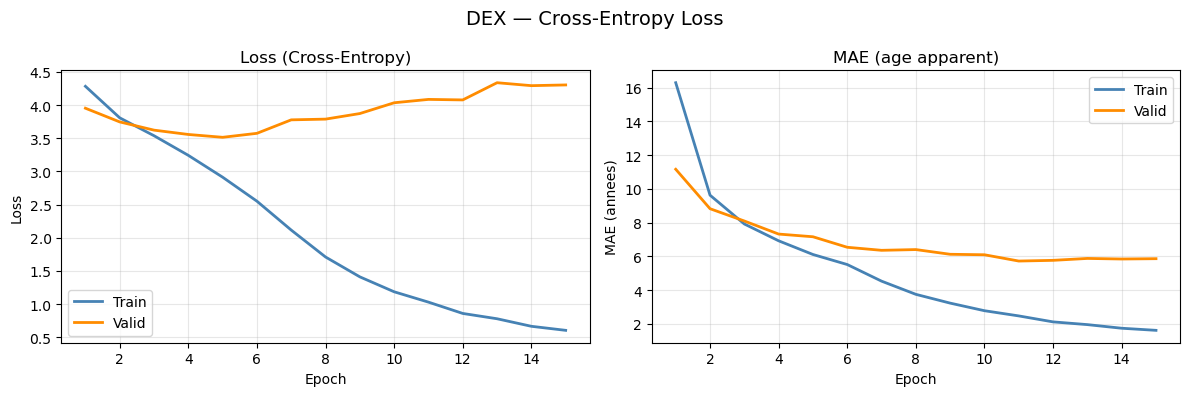

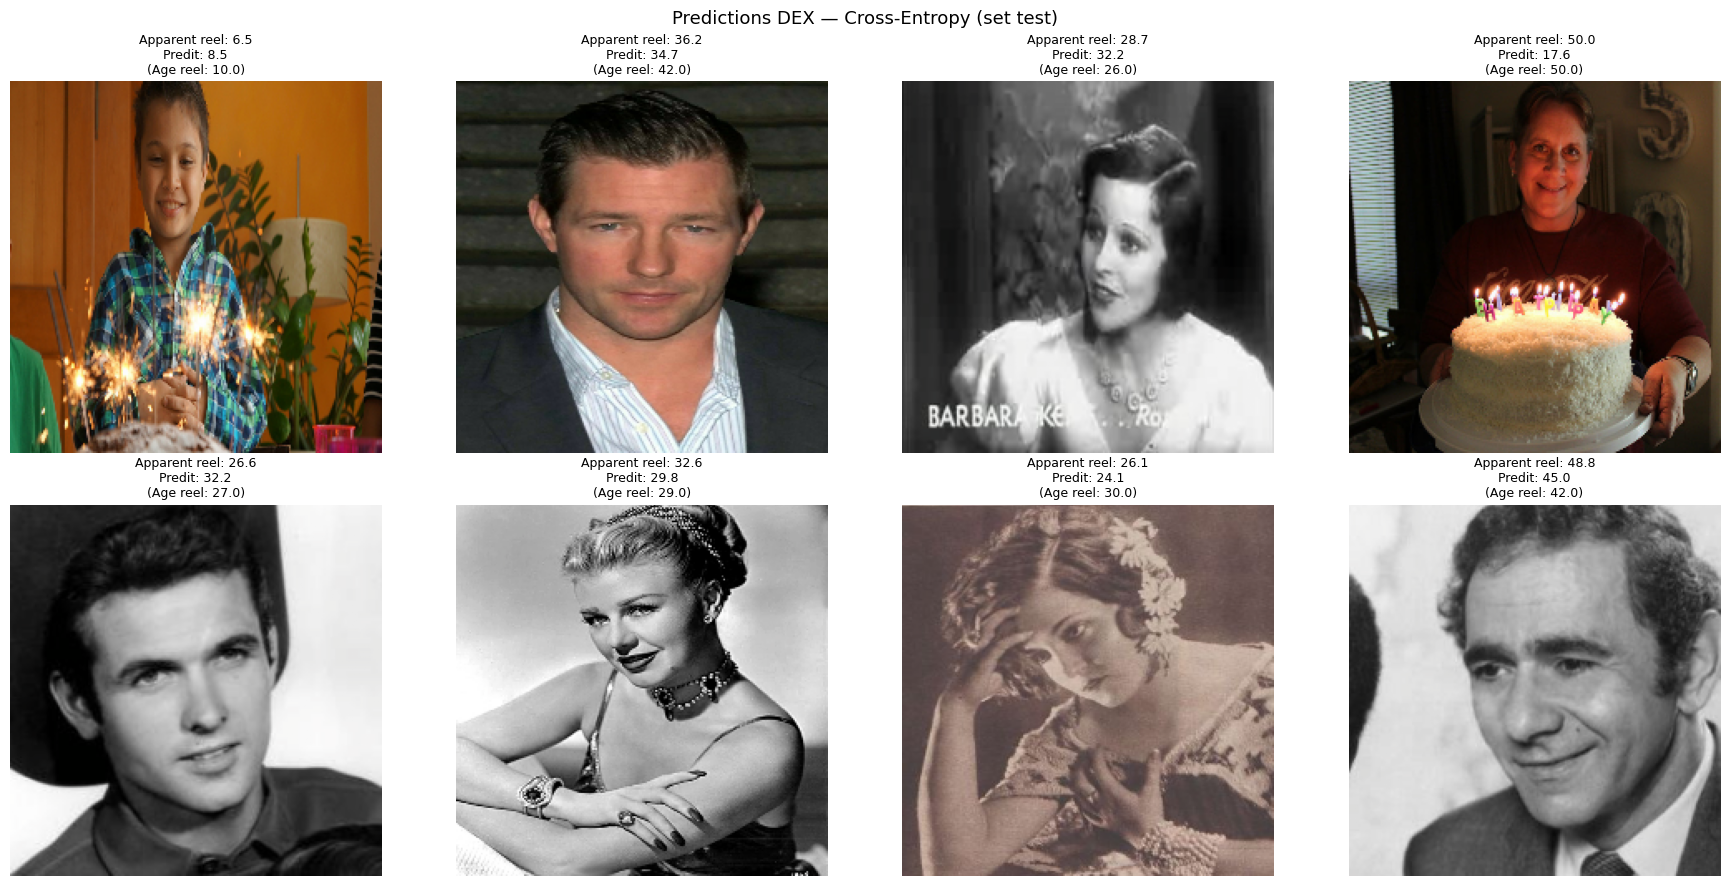

In [13]:
# ============================================================
# Evaluation test + Courbes + Predictions — Cross-Entropy
# ============================================================
ckpt = torch.load(CE_CKPT_DIR/"dex_ce_best.pth", map_location=device)
model_ce.load_state_dict(ckpt["state_dict"]); model_ce.eval()

total_app, total_real, n = 0., 0., 0
with torch.no_grad():
    for imgs, _, age_float, real_age, std in test_loader_ce:
        imgs = imgs.to(device)
        age_float = age_float.to(device, dtype=torch.float32)
        real_age  = real_age.to(device,  dtype=torch.float32)
        _, probs = model_ce(imgs); pred = calculate_expected_age(probs, device)
        total_app  += torch.abs(pred - age_float).sum().item()
        total_real += torch.abs(pred - real_age).sum().item(); n += imgs.size(0)

mae_app_ce  = total_app  / n
mae_real_ce = total_real / n
print(f"--- RESULTATS TEST (Cross-Entropy) ---")
print(f"MAE Age Apparent : {mae_app_ce:.2f} ans")
print(f"MAE Age Reel     : {mae_real_ce:.2f} ans")

# Courbes
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax,(key_tr,key_val,title,ylabel) in zip(axes,[
    ("train_loss","val_loss","Loss (Cross-Entropy)","Loss"),
    ("train_mae","val_mae","MAE (age apparent)","MAE (annees)")
]):
    ax.plot(history_ce["epoch"], history_ce[key_tr], label="Train", color="steelblue",  lw=2)
    ax.plot(history_ce["epoch"], history_ce[key_val],label="Valid", color="darkorange", lw=2)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.legend(); ax.grid(True,alpha=0.3)
plt.suptitle("DEX — Cross-Entropy Loss", fontsize=14)
plt.tight_layout(); plt.savefig("courbes_ce.png",dpi=150); plt.show()

# Predictions visuelles
indices = np.random.choice(len(test_ds), 8, replace=False)
fig, axes = plt.subplots(2,4,figsize=(18,9))
for i, idx in enumerate(indices):
    img_t,_,app_age,real_age,_ = test_ds[idx]
    with torch.no_grad():
        _, probs = model_ce(img_t.unsqueeze(0).to(device))
        pred = calculate_expected_age(probs, device).item()
    axes[i//4,i%4].imshow(denormalize(img_t))
    axes[i//4,i%4].set_title(f"Apparent reel: {app_age:.1f}\nPredit: {pred:.1f}\n(Age reel: {float(real_age):.1f})", fontsize=9)
    axes[i//4,i%4].axis("off")
plt.suptitle("Predictions DEX — Cross-Entropy (set test)", fontsize=13)
plt.tight_layout(); plt.savefig("predictions_ce.png",dpi=150); plt.show()



# Partie 2 — DEX avec Gaussian Loss

## Motivation : Cible floue vs cible dure

La Cross-Entropy classique utilise une **cible dure** (one-hot).
Si l’âge apparent annoté est 26 ans, alors :

* seule la classe 26 vaut 1
* toutes les autres classes valent 0

Cette formulation force le modèle à prédire **exactement 26**, sans tolérer les valeurs proches.
Or, **l’âge apparent est subjectif** : 25, 26 ou 27 peuvent tous être considérés comme “justes” selon les annotateurs.

Pour mieux refléter cette incertitude, la Gaussian Loss remplace le one-hot par une **distribution floue** :

$$Q(k) = \frac{1}{Z} \exp\left(-\frac{(k - \bar{y})^2}{2\sigma^2}\right)$$

où :

$\bar{y}$ = age apparent annote

$\sigma$ = largeur de la gaussienne (incertitude)

$Z$ = normalisation

Ainsi, la cible dit :
*“25, 26 et 27 sont probables ; 10 ou 70 ne le sont pas.”*

Ensuite on doit donc comparer :

* la distribution vraie ( Q(k) )
* la distribution prédite ( P(k $\mid x$) )

La manière standard de comparer deux distributions est la **cross-entropy** :

$$\mathcal{L}_{\text{Gauss}} = -\sum_{k=0}^{100} Q(k)\log P(k\mid x)$$

Interprétation :
pour chaque âge (k) :
* si **Q(k) est grand**, alors *P(k)* doit être grand
  → sinon la loss explose
* si **Q(k) est petit**, le terme contribue peu

Le modèle apprend donc à reproduire **toute la distribution**,
et pas seulement une classe unique.

## Pourquoi la Gaussian Loss est meilleure que la Cross-Entropy ?

### **1. Elle reflète l’incertitude humaine**

Les annotateurs ne sont jamais parfaitement d’accord, une cible floue capture mieux cette réalité.

### **2. Elle pénalise moins les petites erreurs**

Prédire 25 quand la vérité apparente est 26 n’est plus considéré comme “faux total”.

### **3. Elle stabilise l’apprentissage**

Les gradients deviennent plus doux = convergence plus stable.

### **4. Elle généralise mieux**




## 📝 Conclusion

La Gaussian Loss représente une avancée majeure par rapport à la Cross-Entropy :

* Elle capture **l’incertitude naturelle** de l’âge apparent.
* Elle stabilise l’entraînement grâce à des gradients plus doux.
* Elle apprend une représentation **plus continue** et plus cohérente de l’âge.
* Elle offre des performances supérieures, plus robustes et plus humaines.

En remplaçant une cible dure par une distribution gaussienne floue,
on passe d’un apprentissage basé sur le “tout ou rien”
à un apprentissage **informatif, continu et physiologiquement réaliste**.



### Paramètres — DEX Gaussian Loss

In [14]:
# ============================================================
# PARAMETRES — DEX Gaussian Loss 
# ============================================================

GAUSS_EPOCHS     = 15    # Nombre d'epochs
GAUSS_BATCH_SIZE = 64    # Taille des batches
GAUSS_LR         = 1e-4  # Learning rate (Adam)
GAUSS_DROPOUT    = 0.5   # Dropout dans la tete de classification
GAUSS_SIGMA      = 2.0   # Ecart-type de la gaussienne cible (en annees)
GAUSS_CKPT_DIR   = Path("checkpoint_gauss")  # Dossier de sauvegarde

print(f"Epochs     : {GAUSS_EPOCHS}")
print(f"Batch size : {GAUSS_BATCH_SIZE}")
print(f"LR         : {GAUSS_LR}")
print(f"Dropout    : {GAUSS_DROPOUT}")
print(f"Sigma      : {GAUSS_SIGMA} ans")

Epochs     : 15
Batch size : 64
LR         : 0.0001
Dropout    : 0.5
Sigma      : 2.0 ans


In [15]:
# ============================================================
# Partie 2 : Entrainement DEX — Gaussian Loss
# ============================================================
gc.collect(); torch.cuda.empty_cache()
GAUSS_CKPT_DIR.mkdir(exist_ok=True)

train_loader_gauss = DataLoader(train_ds, batch_size=GAUSS_BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader_gauss = DataLoader(valid_ds, batch_size=GAUSS_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_gauss  = DataLoader(test_ds,  batch_size=GAUSS_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

model_gauss     = DEXModel(num_classes=NUM_CLASSES, dropout=GAUSS_DROPOUT).to(device)
optimizer_gauss = optim.Adam(model_gauss.parameters(), lr=GAUSS_LR)
scaler_gauss    = amp.GradScaler(device=str(device))
history_gauss   = {"epoch":[],"train_loss":[],"train_mae":[],"val_loss":[],"val_mae":[]}

def gaussian_loss(probs, age_float, sigma=GAUSS_SIGMA):
    y = age_float.clamp(0, NUM_CLASSES-1).unsqueeze(1)
    age_range = torch.arange(NUM_CLASSES, device=device).view(1,-1).float()
    gauss = torch.exp(-0.5 * ((age_range - y) / sigma) ** 2)
    gauss = gauss / gauss.sum(dim=1, keepdim=True)
    return -(gauss * torch.log(probs + 1e-8)).sum(dim=1).mean()

def epoch_loop_gauss(loader, model, optimizer, train=True):
    model.train() if train else model.eval()
    total_loss, total_mae, n = 0., 0., 0
    for imgs, age_class, age_float, real_age, std in loader:
        imgs = imgs.to(device, non_blocking=True)
        age_float = age_float.to(device, dtype=torch.float32)
        if train: optimizer.zero_grad(set_to_none=True)
        with amp.autocast(device_type=str(device)):
            _, probs = model(imgs)
            loss = gaussian_loss(probs, age_float, sigma=GAUSS_SIGMA)
            pred = calculate_expected_age(probs, device)
        mae = torch.abs(pred - age_float).sum()
        if train:
            scaler_gauss.scale(loss).backward(); scaler_gauss.step(optimizer); scaler_gauss.update()
        bs = imgs.size(0); total_loss += loss.item()*bs; total_mae += mae.item(); n += bs
    return total_loss/n, total_mae/n

best_gauss_mae = math.inf
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7}")
print("-"*55)
for epoch in range(1, GAUSS_EPOCHS+1):
    t0 = time.time()
    tl, tm = epoch_loop_gauss(train_loader_gauss, model_gauss, optimizer_gauss, train=True)
    with torch.no_grad(): vl, vm = epoch_loop_gauss(valid_loader_gauss, model_gauss, optimizer_gauss, train=False)
    history_gauss["epoch"].append(epoch); history_gauss["train_loss"].append(tl); history_gauss["train_mae"].append(tm)
    history_gauss["val_loss"].append(vl); history_gauss["val_mae"].append(vm)
    print(f"{epoch:>5} | {tl:>10.4f} | {tm:>9.2f} | {vl:>8.4f} | {vm:>7.2f}  ({time.time()-t0:.1f}s)")
    if vm < best_gauss_mae:
        best_gauss_mae = vm
        torch.save({"epoch":epoch,"state_dict":model_gauss.state_dict(),"val_mae":vm}, GAUSS_CKPT_DIR/"dex_gauss_best.pth")
        print(f"         Nouveau meilleur modele (MAE={vm:.2f})")
    torch.cuda.empty_cache()
print(f"\nEntrainement Gauss termine. Meilleur MAE Val : {best_gauss_mae:.2f}")

Epoch | Train Loss | Train MAE | Val Loss | Val MAE
-------------------------------------------------------
    1 |     4.1567 |     13.53 |   3.8134 |    9.90  (13.8s)
         Nouveau meilleur modele (MAE=9.90)
    2 |     3.6682 |      7.70 |   3.4777 |    7.04  (13.8s)
         Nouveau meilleur modele (MAE=7.04)
    3 |     3.3436 |      5.53 |   3.4570 |    6.25  (13.7s)
         Nouveau meilleur modele (MAE=6.25)
    4 |     3.0971 |      4.14 |   3.3601 |    5.82  (13.8s)
         Nouveau meilleur modele (MAE=5.82)
    5 |     2.9309 |      3.42 |   3.3991 |    5.51  (13.7s)
         Nouveau meilleur modele (MAE=5.51)
    6 |     2.8052 |      2.82 |   3.4050 |    5.45  (13.8s)
         Nouveau meilleur modele (MAE=5.45)
    7 |     2.7276 |      2.52 |   3.4218 |    5.49  (13.8s)
    8 |     2.6331 |      2.16 |   3.3722 |    5.15  (13.8s)
         Nouveau meilleur modele (MAE=5.15)
    9 |     2.5601 |      1.91 |   3.5022 |    5.28  (13.8s)
   10 |     2.4911 |      1.64 |   

--- RESULTATS TEST (Gaussian Loss) ---
MAE Age Apparent : 6.47 ans
MAE Age Reel     : 8.56 ans


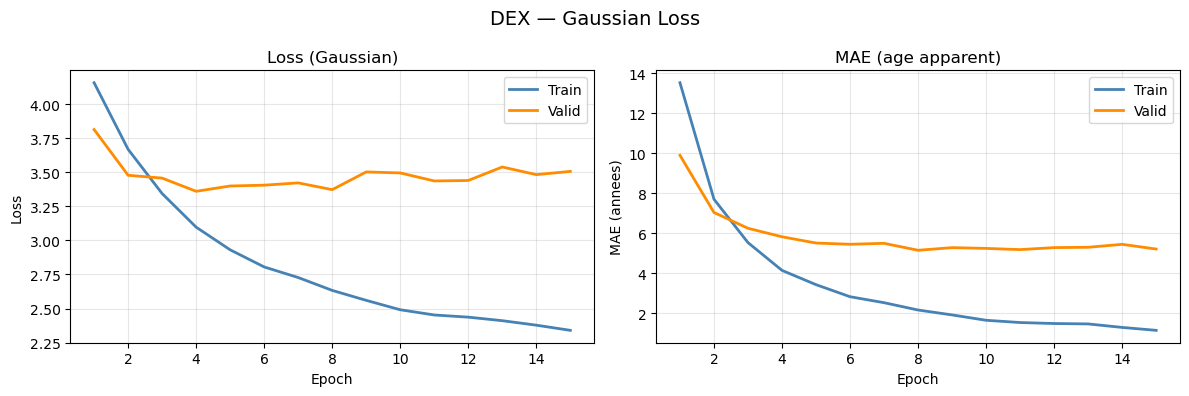

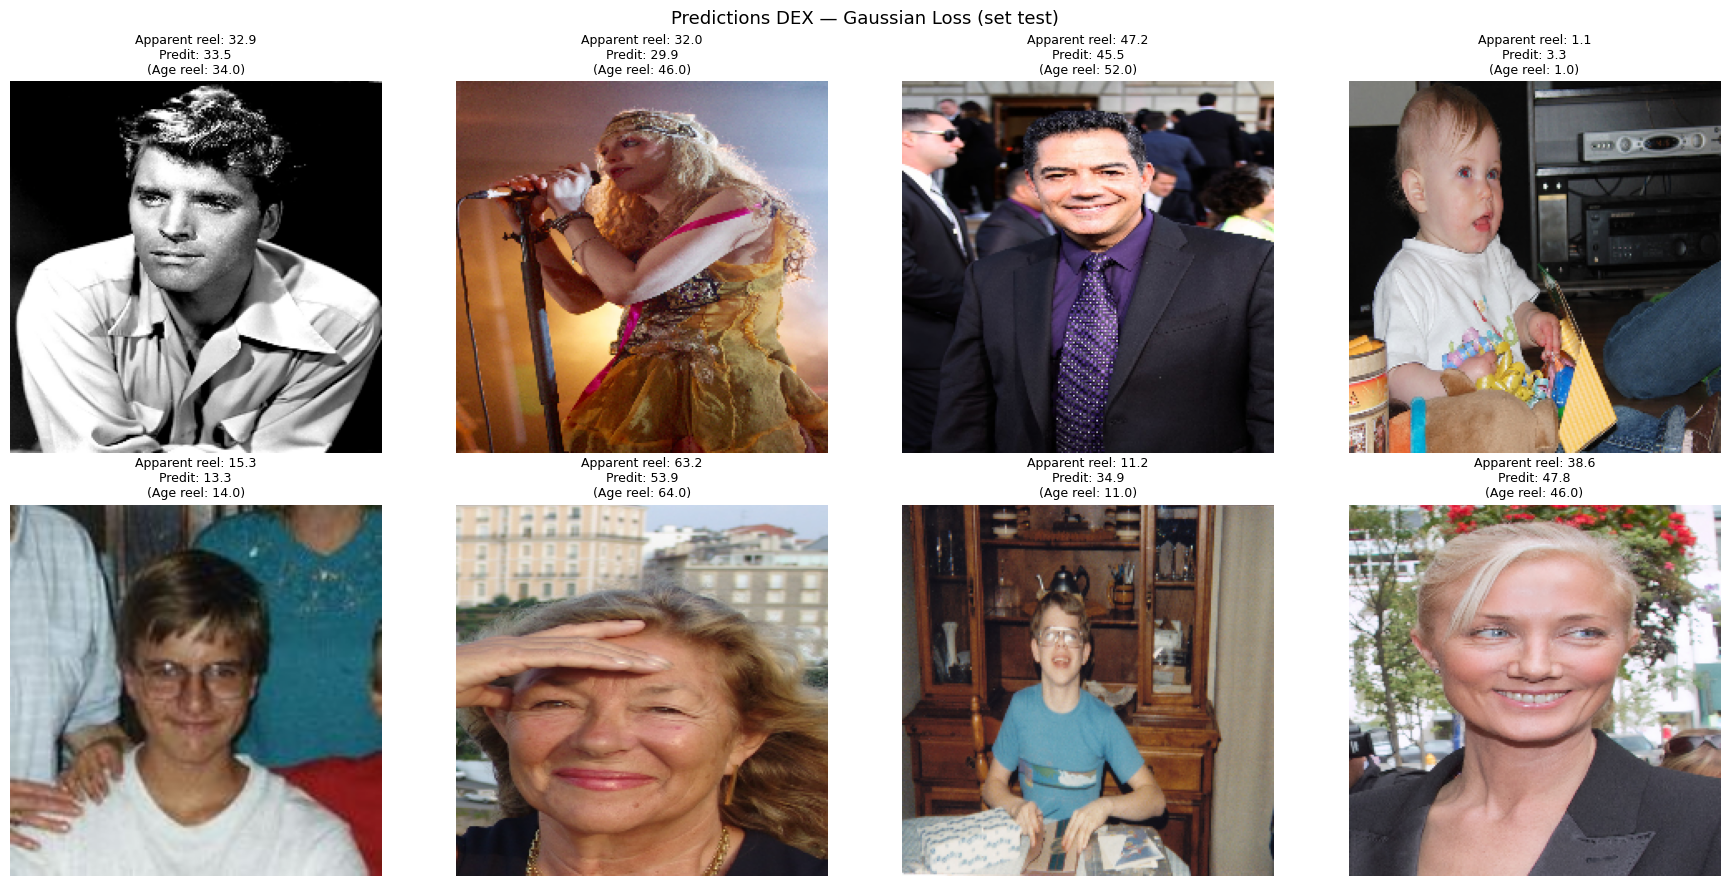

In [16]:
# ============================================================
# Evaluation test + Courbes + Predictions — Gaussian Loss
# ============================================================
ckpt = torch.load(GAUSS_CKPT_DIR/"dex_gauss_best.pth", map_location=device)
model_gauss.load_state_dict(ckpt["state_dict"]); model_gauss.eval()

total_app, total_real, n = 0., 0., 0
with torch.no_grad():
    for imgs, _, age_float, real_age, std in test_loader_gauss:
        imgs = imgs.to(device)
        age_float = age_float.to(device, dtype=torch.float32)
        real_age  = real_age.to(device,  dtype=torch.float32)
        _, probs = model_gauss(imgs); pred = calculate_expected_age(probs, device)
        total_app  += torch.abs(pred - age_float).sum().item()
        total_real += torch.abs(pred - real_age).sum().item(); n += imgs.size(0)

mae_app_gauss  = total_app  / n
mae_real_gauss = total_real / n
print(f"--- RESULTATS TEST (Gaussian Loss) ---")
print(f"MAE Age Apparent : {mae_app_gauss:.2f} ans")
print(f"MAE Age Reel     : {mae_real_gauss:.2f} ans")

# Courbes
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax,(key_tr,key_val,title,ylabel) in zip(axes,[
    ("train_loss","val_loss","Loss (Gaussian)","Loss"),
    ("train_mae","val_mae","MAE (age apparent)","MAE (annees)")
]):
    ax.plot(history_gauss["epoch"], history_gauss[key_tr], label="Train", color="steelblue",  lw=2)
    ax.plot(history_gauss["epoch"], history_gauss[key_val],label="Valid", color="darkorange", lw=2)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.legend(); ax.grid(True,alpha=0.3)
plt.suptitle("DEX — Gaussian Loss", fontsize=14)
plt.tight_layout(); plt.savefig("courbes_gauss.png",dpi=150); plt.show()

# Predictions visuelles
indices = np.random.choice(len(test_ds), 8, replace=False)
fig, axes = plt.subplots(2,4,figsize=(18,9))
for i, idx in enumerate(indices):
    img_t,_,app_age,real_age,_ = test_ds[idx]
    with torch.no_grad():
        _, probs = model_gauss(img_t.unsqueeze(0).to(device))
        pred = calculate_expected_age(probs, device).item()
    axes[i//4,i%4].imshow(denormalize(img_t))
    axes[i//4,i%4].set_title(f"Apparent reel: {app_age:.1f}\nPredit: {pred:.1f}\n(Age reel: {float(real_age):.1f})", fontsize=9)
    axes[i//4,i%4].axis("off")
plt.suptitle("Predictions DEX — Gaussian Loss (set test)", fontsize=13)
plt.tight_layout(); plt.savefig("predictions_gauss.png",dpi=150); plt.show()

---
# Partie 3 — Residual DEX

## Motivation : Âge apparent vs âge réel

Les méthodes DEX prédisent l'âge apparent. Or :
$$y_{\text{real}} = y_{\text{app}} + \Delta$$

**Residual DEX** ajoute une branche résiduelle pour apprendre $\Delta$ :

$$\hat{y}_{\text{app}} = \sum_{k=0}^{100} k \cdot P(k \mid \mathbf{x}), \quad \hat{\Delta} = r_\phi(\mathbf{f}), \quad \hat{y}_{\text{real}} = \hat{y}_{\text{app}} + \hat{\Delta}$$

## Stratégie d'entraînement en 3 phases

| Phase | Modules entraînés | Loss | Objectif |
|-------|-------------------|------|----------|
| 1 | Tête DEX uniquement | $\mathcal{L}_{\text{CE}}$ | Apprendre l'âge apparent |
| 2 | Tête résiduelle uniquement | $\mathcal{L}_{\text{Huber}}$ | Apprendre la correction |
| 3 | Toutes les têtes | $\alpha \mathcal{L}_{\text{CE}} + \beta \mathcal{L}_{\text{Huber}}$ | Fine-tuning global |

La **Huber Loss** est robuste aux outliers :
$$\mathcal{L}_{\text{Huber}}(\hat{y}, y) = \begin{cases} \frac{1}{2}(\hat{y}-y)^2 & \text{si } |\hat{y}-y| \leq 1 \\ |\hat{y}-y| - \frac{1}{2} & \text{sinon} \end{cases}$$

### Paramètres — Residual DEX

In [17]:
# ============================================================
# PARAMETRES — Residual DEX 
# ============================================================

RD_BATCH_SIZE = 64      # Taille des batches
RD_DROPOUT    = 0.6     # Dropout dans les tetes DEX et residuelle

# Phases d'entrainement
RD_EPOCHS_P1  = 15      # Epochs Phase 1 : DEX seul
RD_EPOCHS_P2  = 10      # Epochs Phase 2 : Residu seul
RD_EPOCHS_P3  = 5      # Epochs Phase 3 : Fine-tuning global

# Learning rates
RD_LR_P1      = 1e-4    # LR Phase 1
RD_LR_P2      = 1e-4    # LR Phase 2
RD_LR_P3      = 1e-5    # LR Phase 3 (plus faible pour le fine-tuning)

# Coefficients de la loss en Phase 3
RD_ALPHA_P3   = 1.0     # Poids de la loss DEX en Phase 3
RD_BETA_P3    = 1.0     # Poids de la loss residuelle en Phase 3

print(f"Batch size    : {RD_BATCH_SIZE}")
print(f"Dropout       : {RD_DROPOUT}")
print(f"Epochs P1/P2/P3 : {RD_EPOCHS_P1} / {RD_EPOCHS_P2} / {RD_EPOCHS_P3}")
print(f"LR P1/P2/P3   : {RD_LR_P1} / {RD_LR_P2} / {RD_LR_P3}")
print(f"Alpha/Beta P3 : {RD_ALPHA_P3} / {RD_BETA_P3}")

Batch size    : 64
Dropout       : 0.6
Epochs P1/P2/P3 : 15 / 10 / 5
LR P1/P2/P3   : 0.0001 / 0.0001 / 1e-05
Alpha/Beta P3 : 1.0 / 1.0


In [18]:
# ============================================================
# Modele Residual DEX
# ============================================================
gc.collect(); torch.cuda.empty_cache()

class ResidualDEXModel(nn.Module):
    def __init__(self, num_classes=101, dropout=0.6):
        super().__init__()
        # 1 seul backbone, partage pour les 2 têtes
        self.feature_extractor = get_model(
            "se_resnext50_32x4d",
            num_classes=num_classes,
            pretrained="imagenet"
        )
        dim = self.feature_extractor.last_linear.in_features

        # On coupe la tête ImageNet : la sortie du modèle devient un vecteur de features
        self.feature_extractor.last_linear = nn.Identity()

        # Tête DEX (âge apparent)
        self.dex_head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

        # Tête résiduelle (delta entre apparent et réel)
        self.residual_head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(dim, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1),
        )

        # IMPORTANT : on initialise la dernière couche résiduelle à 0
        # => au début, le modèle prédit "age_real ≈ age_apparent"
        last_linear = self.residual_head[-1]
        nn.init.zeros_(last_linear.weight)
        nn.init.zeros_(last_linear.bias)

    def forward(self, x):
        # 1 backbone commun
        feats = self.feature_extractor(x)          # shape (B, dim)

        # Tête DEX
        logits = self.dex_head(feats)             # (B, num_classes)
        probs  = torch.softmax(logits, dim=1)

        # Tête résiduelle
        res    = self.residual_head(feats).squeeze(1)   # (B,)

        return logits, probs, res


def set_trainable(model, phase):
    """
    phase 1 : on entraîne backbone + tête DEX (comme un DEX classique)
    phase 2 : on gèle backbone + DEX, on entraîne seulement la tête résiduelle
    phase 3 : fine-tuning global : backbone + DEX + résiduel (LR plus faible)
    """
    # Tout geler
    for p in model.parameters():
        p.requires_grad = False

    if phase == 1:
        modules = [model.feature_extractor, model.dex_head]
    elif phase == 2:
        modules = [model.residual_head]
    elif phase == 3:
        modules = [model.feature_extractor, model.dex_head, model.residual_head]
    else:
        raise ValueError(f"Phase inconnue : {phase}")

    for m in modules:
        for p in m.parameters():
            p.requires_grad = True

    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parametres entrainables (phase {phase}) : {n:,}")

model_resdex = ResidualDEXModel(num_classes=NUM_CLASSES, dropout=RD_DROPOUT).to(device)
print("ResidualDEX Model charge sur", device)

ResidualDEX Model charge sur cuda


In [19]:
# ============================================================
# Boucles train/valid — Residual DEX
# ============================================================
criterion_dex = nn.CrossEntropyLoss()
criterion_res = nn.HuberLoss()
scaler_rd     = amp.GradScaler(device=str(device))

train_loader_rd = DataLoader(train_ds, batch_size=RD_BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader_rd = DataLoader(valid_ds, batch_size=RD_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_rd  = DataLoader(test_ds,  batch_size=RD_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

history_rd = {"epoch":[],"phase":[],"loss_dex":[],"loss_res":[],"mae_app":[],"mae_real":[]}

def train_one_epoch_rd(model, loader, optimizer, alpha=1.0, beta=1.0):
    model.train()
    td, tr, n = 0., 0., 0
    for imgs, age_class, age_float, real_age, std in loader:
        imgs = imgs.to(device, non_blocking=True)
        age_class = age_class.to(device)
        age_float = age_float.to(device, dtype=torch.float32)
        real_age  = real_age.to(device,  dtype=torch.float32)
        optimizer.zero_grad(set_to_none=True)
        with amp.autocast(device_type=str(device)):
            logits, probs, res = model(imgs)
            pred_app  = calculate_expected_age(probs, device)
            pred_real = pred_app + res
            ld = criterion_dex(logits, age_class) if alpha > 0 else torch.tensor(0.)
            lr = criterion_res(pred_real, real_age) if beta > 0 else torch.tensor(0.)
            loss = alpha*ld + beta*lr
        scaler_rd.scale(loss).backward(); scaler_rd.step(optimizer); scaler_rd.update()
        bs = imgs.size(0); td += ld.item()*bs; tr += lr.item()*bs; n += bs
    return td/n, tr/n

def validate_rd(model, loader):
    model.eval()
    ta, tr, n = 0., 0., 0
    with torch.no_grad():
        for imgs, _, age_float, real_age, std in loader:
            imgs = imgs.to(device)
            age_float = age_float.to(device, dtype=torch.float32)
            real_age  = real_age.to(device,  dtype=torch.float32)
            _, probs, res = model(imgs)
            pred_app  = calculate_expected_age(probs, device)
            pred_real = pred_app + res
            ta += torch.abs(pred_app  - age_float).sum().item()
            tr += torch.abs(pred_real - real_age).sum().item(); n += imgs.size(0)
    return ta/n, tr/n

print("Boucles pretes.")

Boucles pretes.


In [20]:
# ============================================================
# Entrainement Residual DEX — 3 phases
# ============================================================
best_mae_real = math.inf
epoch_global  = 0
total_epochs  = RD_EPOCHS_P1 + RD_EPOCHS_P2 + RD_EPOCHS_P3

def print_progress_rd(phase, epoch, total, ld, lr, ma, mr, eg, te, t):
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.memory_allocated() / 1024**3
        gpu_tot = torch.cuda.get_device_properties(0).total_memory / 1024**3
        gpu_str = f"GPU:{gpu_mem:.1f}/{gpu_tot:.1f}GB"
    else:
        gpu_str = "GPU:CPU-only"

    bar = chr(9608)*int(30*eg/te) + chr(9617)*(30-int(30*eg/te))
    print(
        f"[{bar}] {eg}/{te} | P{phase} Ep {epoch}/{total} | "
        f"DEX:{ld:.4f} Res:{lr:.4f} | MAE App:{ma:.2f} Real:{mr:.2f} | "
        f"{gpu_str} | {t:.1f}s"
    )

# Config des 3 phases :
#  - alpha = poids de la loss DEX
#  - beta  = poids de la loss residuelle
phases_config = [
    # Phase 1 : on apprend DEX (apparent) uniquement
    {"phase": 1, "epochs": RD_EPOCHS_P1, "lr": RD_LR_P1, "alpha": 1.0,          "beta": 0.0},
    # Phase 2 : on apprend le résidu (réel - apparent) uniquement
    {"phase": 2, "epochs": RD_EPOCHS_P2, "lr": RD_LR_P2, "alpha": 0.0,          "beta": 1.0},
    # Phase 3 : fine-tuning global (apparent + réel)
    {"phase": 3, "epochs": RD_EPOCHS_P3, "lr": RD_LR_P3, "alpha": RD_ALPHA_P3,  "beta": RD_BETA_P3},
]

print("Debut de l'entrainement Residual DEX...")

for cfg in phases_config:
    phase = cfg["phase"]
    epochs = cfg["epochs"]
    lr     = cfg["lr"]
    alpha  = cfg["alpha"]
    beta   = cfg["beta"]

    if epochs == 0:
        continue

    print(f"\n Phase {phase} — {epochs} epochs (lr={lr})")
    set_trainable(model_resdex, phase)

    # Optimiseur identique à DEX CE : Adam 
    optimizer = optim.Adam(
        [p for p in model_resdex.parameters() if p.requires_grad],
        lr=lr,
    )

    for epoch in range(1, epochs+1):
        epoch_global += 1
        t0 = time.time()

        ld, lr_ = train_one_epoch_rd(model_resdex, train_loader_rd, optimizer, alpha=alpha, beta=beta)
        ma, mr  = validate_rd(model_resdex, valid_loader_rd)

        history_rd["epoch"].append(epoch_global)
        history_rd["phase"].append(phase)
        history_rd["loss_dex"].append(ld)
        history_rd["loss_res"].append(lr_)
        history_rd["mae_app"].append(ma)
        history_rd["mae_real"].append(mr)

        print_progress_rd(phase, epoch, epochs, ld, lr_, ma, mr, epoch_global, total_epochs, time.time()-t0)

        if mr < best_mae_real:
            best_mae_real = mr
            torch.save(model_resdex.state_dict(), "residual_dex_best.pth")
            print(f"  Nouveau meilleur modele (MAE Real: {best_mae_real:.2f})")

    # On sauvegarde l'état du DEX après la phase 1 (optionnel mais pratique)
    if phase == 1:
        torch.save(model_resdex.state_dict(), "phase1_dex.pth")

    torch.cuda.empty_cache()

print(f"\n Entrainement termine. Meilleur MAE Real : {best_mae_real:.2f}")

Debut de l'entrainement Residual DEX...

 Phase 1 — 15 epochs (lr=0.0001)
  Parametres entrainables (phase 1) : 26,611,797
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 1/30 | P1 Ep 1/15 | DEX:4.2109 Res:0.0000 | MAE App:10.44 Real:11.80 | GPU:1.5/15.6GB | 15.3s
  Nouveau meilleur modele (MAE Real: 11.80)
[██░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 2/30 | P1 Ep 2/15 | DEX:3.6186 Res:0.0000 | MAE App:8.10 Real:9.56 | GPU:1.5/15.6GB | 14.9s
  Nouveau meilleur modele (MAE Real: 9.56)
[███░░░░░░░░░░░░░░░░░░░░░░░░░░░] 3/30 | P1 Ep 3/15 | DEX:3.2244 Res:0.0000 | MAE App:7.40 Real:8.87 | GPU:1.5/15.6GB | 14.9s
  Nouveau meilleur modele (MAE Real: 8.87)
[████░░░░░░░░░░░░░░░░░░░░░░░░░░] 4/30 | P1 Ep 4/15 | DEX:2.7769 Res:0.0000 | MAE App:6.77 Real:8.31 | GPU:1.5/15.6GB | 14.9s
  Nouveau meilleur modele (MAE Real: 8.31)
[█████░░░░░░░░░░░░░░░░░░░░░░░░░] 5/30 | P1 Ep 5/15 | DEX:2.2654 Res:0.0000 | MAE App:6.35 Real:7.86 | GPU:1.5/15.6GB | 14.9s
  Nouveau meilleur modele (MAE Real: 7.86)
[██████░░░░░░░░░░░░░░░░░░░░░░░░] 6

--- RESULTATS TEST (Residual DEX) ---
MAE Age Apparent : 6.92 ans
MAE Age Reel     : 8.48 ans


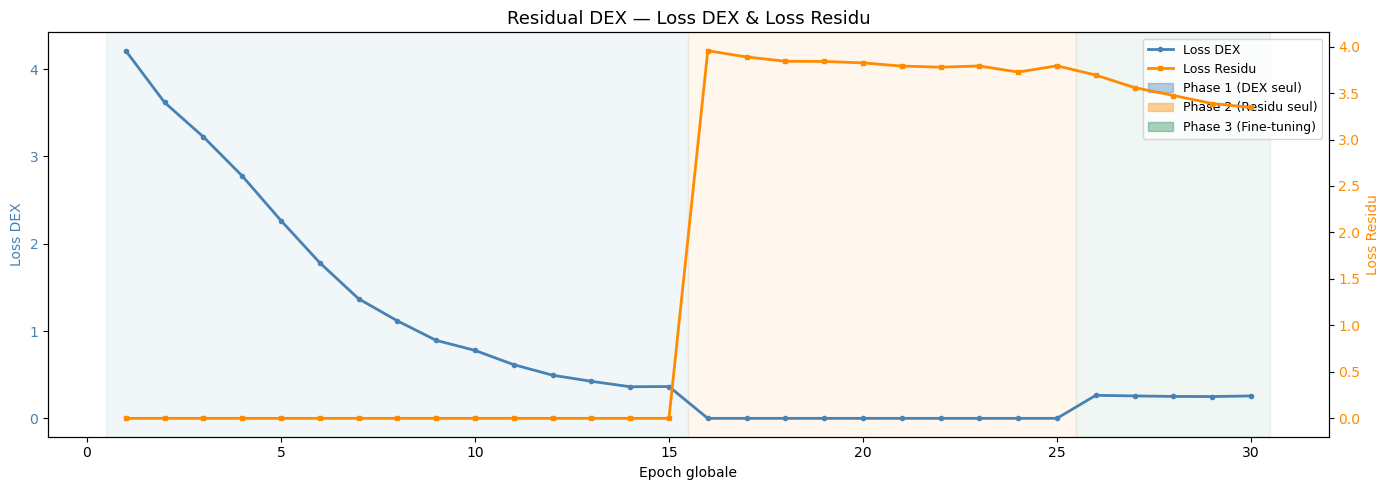

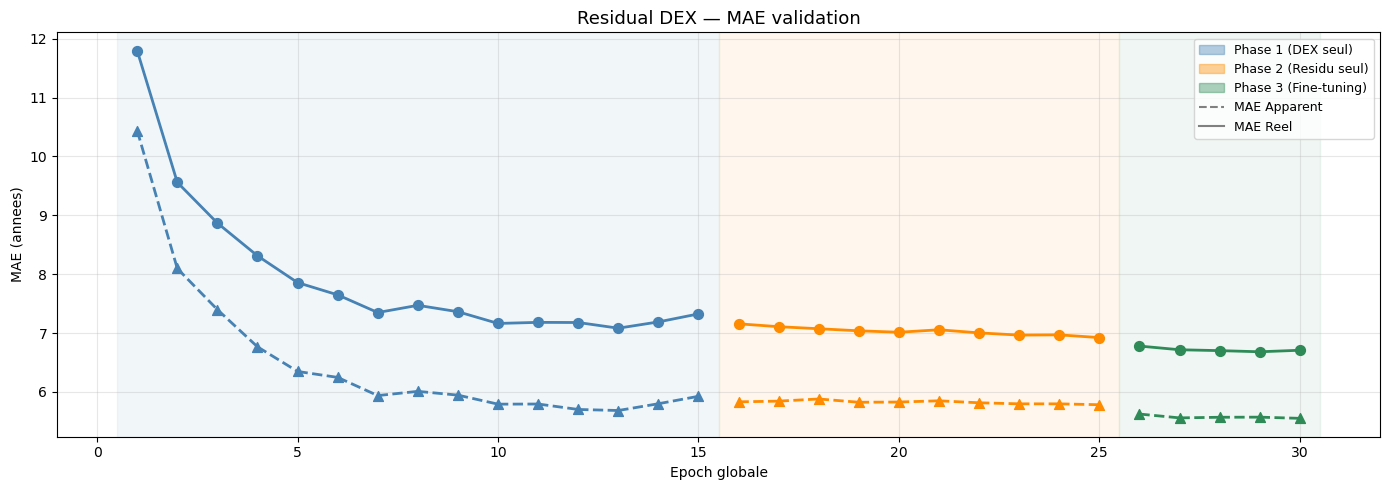

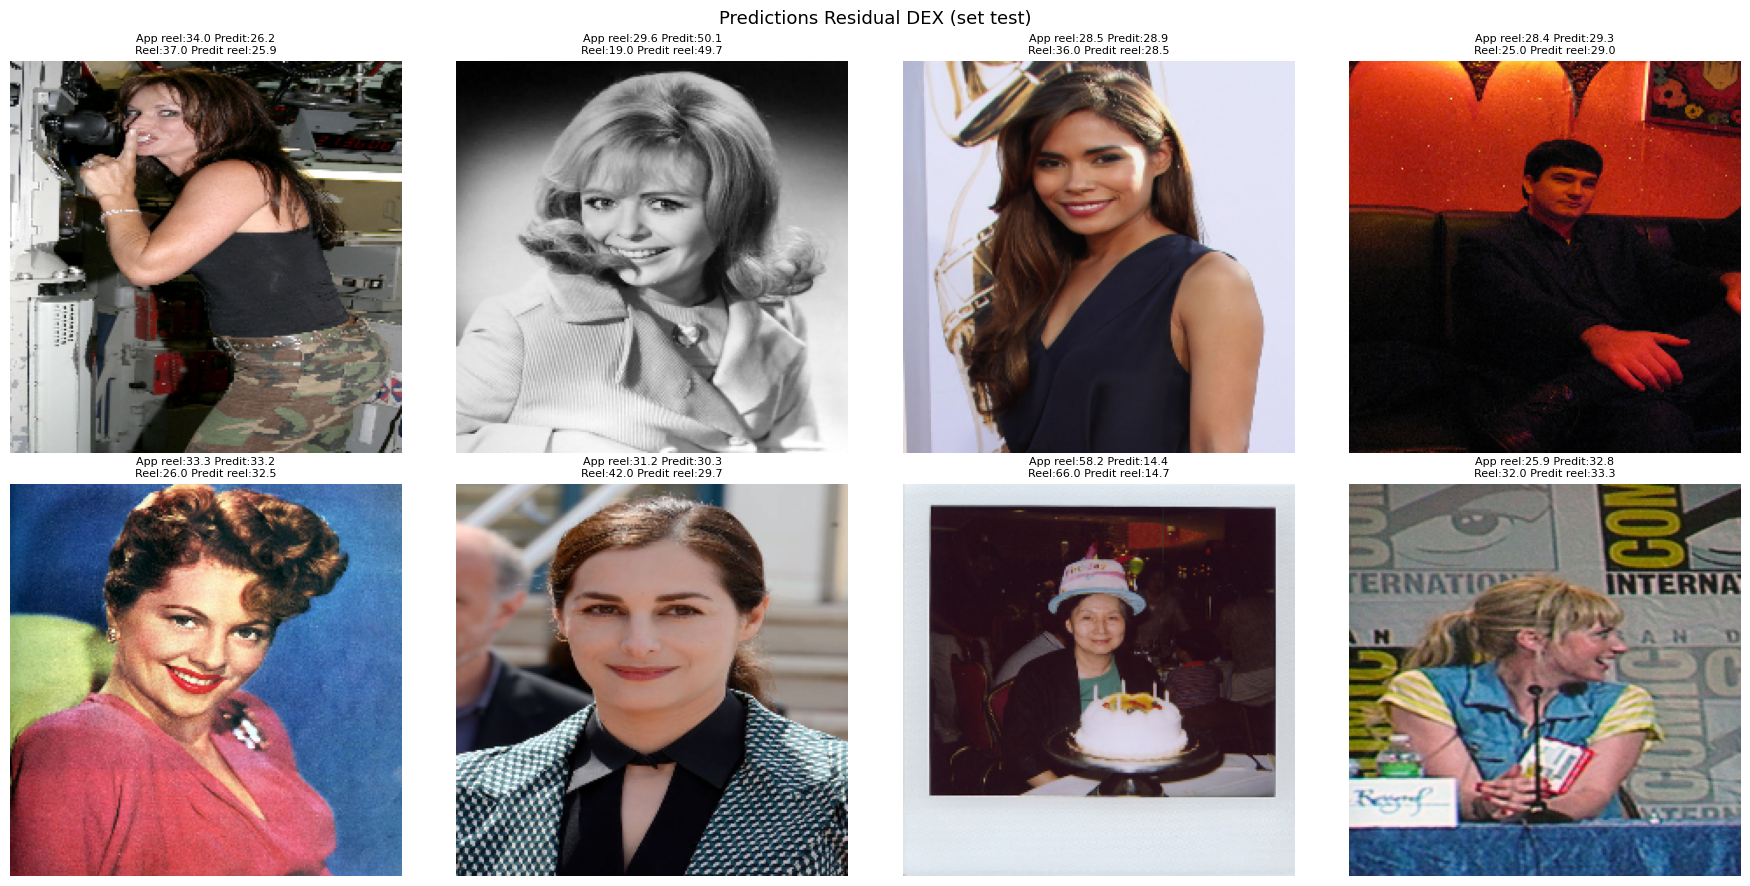

In [21]:
# ============================================================
# Evaluation test + Courbes + Predictions — Residual DEX
# ============================================================
model_resdex.load_state_dict(torch.load("residual_dex_best.pth", map_location=device))
model_resdex.eval()

total_app, total_real, n = 0., 0., 0
with torch.no_grad():
    for imgs, _, age_float, real_age, std in test_loader_rd:
        imgs = imgs.to(device)
        age_float = age_float.to(device, dtype=torch.float32)
        real_age  = real_age.to(device,  dtype=torch.float32)
        _, probs, res = model_resdex(imgs)
        pred_app  = calculate_expected_age(probs, device)
        pred_real = pred_app + res
        total_app  += torch.abs(pred_app  - age_float).sum().item()
        total_real += torch.abs(pred_real - real_age).sum().item(); n += imgs.size(0)

mae_app_rd  = total_app  / n
mae_real_rd = total_real / n
print(f"--- RESULTATS TEST (Residual DEX) ---")
print(f"MAE Age Apparent : {mae_app_rd:.2f} ans")
print(f"MAE Age Reel     : {mae_real_rd:.2f} ans")

# Courbes
epochs_rd = history_rd["epoch"]; phases_rd = history_rd["phase"]
phase_colors = {1:"steelblue", 2:"darkorange", 3:"seagreen"}
phase_labels = {1:"Phase 1 (DEX seul)", 2:"Phase 2 (Residu seul)", 3:"Phase 3 (Fine-tuning)"}

phase_ranges = {}
for e, p in zip(epochs_rd, phases_rd):
    phase_ranges.setdefault(p, [e,e]); phase_ranges[p][1] = e

fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.plot(epochs_rd, history_rd["loss_dex"], color="steelblue",  lw=2, marker="o", ms=3, label="Loss DEX")
ax2.plot(epochs_rd, history_rd["loss_res"], color="darkorange", lw=2, marker="s", ms=3, label="Loss Residu")
ax1.set_xlabel("Epoch globale"); ax1.set_ylabel("Loss DEX",color="steelblue"); ax2.set_ylabel("Loss Residu",color="darkorange")
ax1.tick_params(axis='y',labelcolor="steelblue"); ax2.tick_params(axis='y',labelcolor="darkorange")
for p,(s,e) in phase_ranges.items(): ax1.axvspan(s-0.5,e+0.5,alpha=0.07,color=phase_colors[p])
patches = [mpatches.Patch(color=phase_colors[p], alpha=0.4, label=phase_labels[p]) for p in [1,2,3]]
l1,_ = ax1.get_legend_handles_labels(); l2,_ = ax2.get_legend_handles_labels()
ax1.legend(handles=l1+l2+patches, loc="upper right", fontsize=9)
plt.title("Residual DEX — Loss DEX & Loss Residu",fontsize=13)
plt.tight_layout(); plt.savefig("courbes_resdex_loss.png",dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(14,5))
for i in range(len(epochs_rd)):
    c = phase_colors[phases_rd[i]]
    ax.scatter(epochs_rd[i], history_rd["mae_app"][i],  color=c, s=50, marker="^", zorder=5)
    ax.scatter(epochs_rd[i], history_rd["mae_real"][i], color=c, s=50, marker="o", zorder=5)
    if i < len(epochs_rd)-1 and phases_rd[i]==phases_rd[i+1]:
        ax.plot([epochs_rd[i],epochs_rd[i+1]], [history_rd["mae_app"][i],history_rd["mae_app"][i+1]],  color=c, lw=2, ls="--")
        ax.plot([epochs_rd[i],epochs_rd[i+1]], [history_rd["mae_real"][i],history_rd["mae_real"][i+1]], color=c, lw=2, ls="-")
for p,(s,e) in phase_ranges.items(): ax.axvspan(s-0.5,e+0.5,alpha=0.07,color=phase_colors[p])
la = plt.Line2D([0],[0], color="gray", ls="--", label="MAE Apparent")
lr = plt.Line2D([0],[0], color="gray", ls="-",  label="MAE Reel")
ax.legend(handles=patches+[la,lr],fontsize=9); ax.set_xlabel("Epoch globale"); ax.set_ylabel("MAE (annees)")
ax.set_title("Residual DEX — MAE validation",fontsize=13); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig("courbes_resdex_mae.png",dpi=150); plt.show()

# Predictions visuelles
indices = np.random.choice(len(test_ds), 8, replace=False)
fig, axes = plt.subplots(2,4,figsize=(18,9))
for i, idx in enumerate(indices):
    img_t,_,app_age,real_age,_ = test_ds[idx]
    with torch.no_grad():
        _, probs, res = model_resdex(img_t.unsqueeze(0).to(device))
        pred_app  = calculate_expected_age(probs, device).item()
        pred_real = pred_app + res.item()
    axes[i//4,i%4].imshow(denormalize(img_t))
    axes[i//4,i%4].set_title(f"App reel:{app_age:.1f} Predit:{pred_app:.1f}\nReel:{float(real_age):.1f} Predit reel:{pred_real:.1f}", fontsize=8)
    axes[i//4,i%4].axis("off")
plt.suptitle("Predictions Residual DEX (set test)",fontsize=13)
plt.tight_layout(); plt.savefig("predictions_resdex.png",dpi=150); plt.show()

---
# Partie 4 — Comparaison des méthodes et Conclusion

## Récapitulatif théorique

| Méthode | Loss | Cible | Prédit |
|---------|------|-------|--------|
| DEX (Cross-Entropy) | $-\log P(k^\star)$ | One-hot sur $\text{round}(\bar{y}_{\text{app}})$ | Âge apparent |
| DEX (Gaussian Loss) | $-\sum_k Q(k) \log P(k)$ | Distribution gaussienne $\mathcal{N}(\bar{y}_{\text{app}}, \sigma^2)$ | Âge apparent |
| Residual DEX | $\alpha \mathcal{L}_{\text{CE}} + \beta \mathcal{L}_{\text{Huber}}$ | Apparent + correction résiduelle | Âge apparent **et** réel |

## Comparaison des résultats

          Methode  MAE App (test)  MAE Reel (test)  Delta MAE App->Reel
DEX Cross-Entropy            7.49             9.28                 1.79
DEX Gaussian Loss            6.47             8.56                 2.09
     Residual DEX            6.92             8.48                 1.56


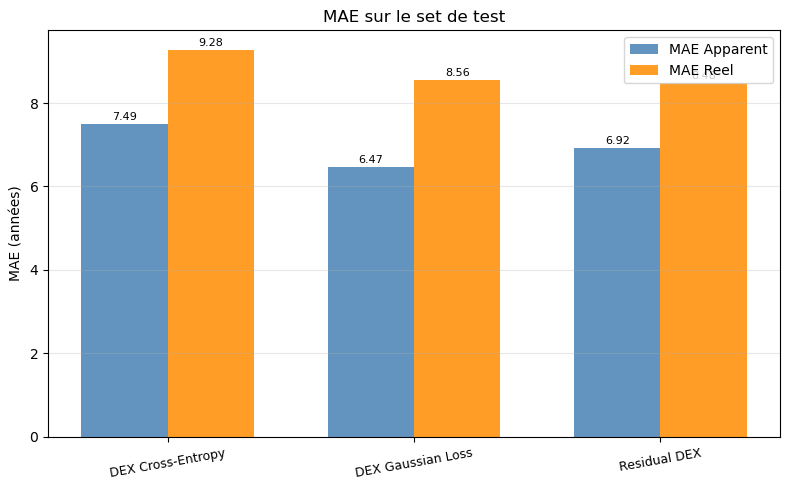

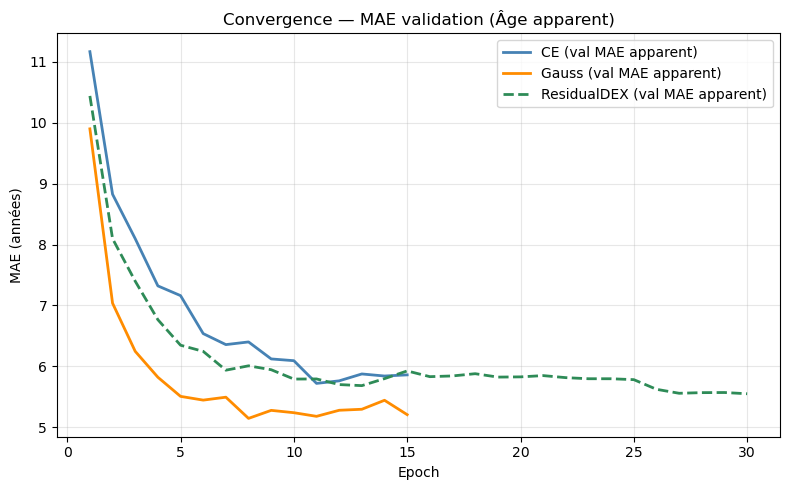

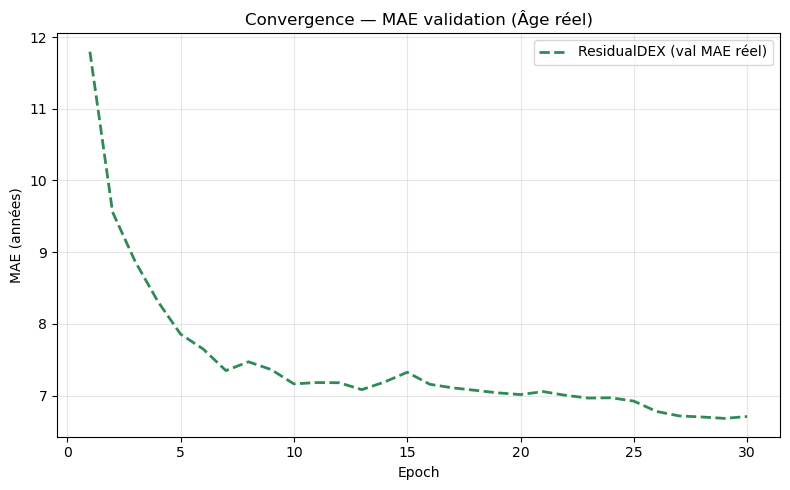

In [22]:
# ============================================================
# Tableau comparatif + Graphiques )
# ============================================================

# -------- Tableau comparatif --------
results = {
    "Methode":         ["DEX Cross-Entropy", "DEX Gaussian Loss", "Residual DEX"],
    "MAE App (test)":  [mae_app_ce,  mae_app_gauss,  mae_app_rd],
    "MAE Reel (test)": [mae_real_ce, mae_real_gauss, mae_real_rd],
}
df_results = pd.DataFrame(results)
df_results["Delta MAE App->Reel"] = df_results["MAE Reel (test)"] - df_results["MAE App (test)"]
print(df_results.to_string(index=False, float_format="{:.2f}".format))

# ============================================================
# FIGURE 1 — MAE sur le test
# ============================================================

fig1, ax1 = plt.subplots(figsize=(8,5))

x = np.arange(len(results["Methode"]))
w = 0.35

b1 = ax1.bar(x-w/2, results["MAE App (test)"],  w, label="MAE Apparent", color="steelblue",  alpha=0.85)
b2 = ax1.bar(x+w/2, results["MAE Reel (test)"], w, label="MAE Reel",     color="darkorange", alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(results["Methode"], rotation=10, fontsize=9)
ax1.set_ylabel("MAE (années)")
ax1.set_title("MAE sur le set de test")
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.05,
             f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("test_mae.png", dpi=150)
plt.show()

# ============================================================
# FIGURE 2 — Convergence MAE validation (âge apparent)
# ============================================================

fig2, ax2 = plt.subplots(figsize=(8,5))

ax2.plot(history_ce["epoch"],    history_ce["val_mae"],
         label="CE (val MAE apparent)", color="steelblue", lw=2)

ax2.plot(history_gauss["epoch"], history_gauss["val_mae"],
         label="Gauss (val MAE apparent)", color="darkorange", lw=2)

ax2.plot(history_rd["epoch"],    history_rd["mae_app"],
         label="ResidualDEX (val MAE apparent)", color="seagreen", lw=2, ls="--")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE (années)")
ax2.set_title("Convergence — MAE validation (Âge apparent)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("convergence_app.png", dpi=150)
plt.show()

# ============================================================
# FIGURE 3 — Convergence MAE validation (âge réel)
# ============================================================

fig3, ax3 = plt.subplots(figsize=(8,5))

ax3.plot(history_rd["epoch"], history_rd["mae_real"],
         label="ResidualDEX (val MAE réel)", color="seagreen", lw=2, ls="--")

ax3.set_xlabel("Epoch")
ax3.set_ylabel("MAE (années)")
ax3.set_title("Convergence — MAE validation (Âge réel)")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("convergence_reel.png", dpi=150)
plt.show()



## Conclusion

Dans ce travail, nous avons évalué trois approches pour la prédiction de l’âge apparent et de l’âge réel à partir d’images faciales : **DEX avec Cross-Entropy**, **DEX optimisé par Gaussian Loss**, et **Residual DEX**, une extension visant à corriger l’âge apparent vers l’âge réel par une prédiction résiduelle.

Les résultats montrent clairement que **la Gaussian Loss est la méthode la plus performante**. Elle offre la meilleure précision à la fois sur l’âge apparent et sur l’âge réel, grâce à une modélisation plus réaliste de la distribution de l’âge. Sa convergence rapide et stable démontre qu’elle est particulièrement adaptée à la nature subjective des annotations d’âge apparent.

La méthode **Cross-Entropy**, bien que simple et efficace, se révèle moins précise. Elle reste une baseline correcte mais souffre de sa formulation trop discrète pour capturer la variabilité des jugements humains, ce qui limite ses performances.

Le modèle **Residual DEX** présente des résultats intéressants. S’il n’atteint pas le niveau de précision de la Gaussian Loss pour l’âge apparent, il parvient toutefois à réduire l’erreur lors de la prédiction de l’âge réel grâce à la correction résiduelle. La convergence progressive et stable du MAE réel montre que la tête résiduelle apprend effectivement à ajuster l’âge apparent vers la vérité terrain. Cependant, son efficacité dépend fortement de la qualité du modèle apparent sous-jacent, et un réglage plus fin serait nécessaire pour exploiter pleinement son potentiel.

En résumé :

* **Gaussian Loss** est la méthode la plus précise et la plus stable : la meilleure option pour l’estimation de l’âge.
* **Residual DEX** apporte une amélioration notable pour l’âge réel et constitue une piste prometteuse pour réduire l’écart apparent–réel.
* **Cross-Entropy** reste utile comme point de comparaison, mais est surpassée par les approches probabilistes.

Ces résultats confirment l’intérêt des méthodes basées sur la distribution et montrent que la correction résiduelle peut améliorer l’estimation de l’âge réel.
